# Ink2Pixel - VLM Proof of Concept

In [1]:
# Auto-reload allows you to make changes to VLM_helper.py 
# and have them immediately reflect here without restarting the kernel.
%load_ext autoreload
%autoreload 2

In [2]:
import torch
from VLM_helper import MathVLMHelper

# Check GPU availability (Expecting RTX 5080)
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# Initialize the helper.
# We use 4-bit quantization by default to easily fit the model + long context in your VRAM.
vlm = MathVLMHelper(model_id="Qwen/Qwen2-VL-7B-Instruct", use_4bit=True)

/home/aidev/anaconda3/envs/ink2pixel/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CUDA Available: True
Device: NVIDIA GeForce RTX 5080
VRAM: 16.61 GB
Loading Qwen/Qwen2-VL-7B-Instruct...


Loading weights: 100%|██████████| 730/730 [00:05<00:00, 133.69it/s]


Model loaded successfully!


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



Processing test_math_images/test1.png...
Generating transcription... (this might take a few seconds)


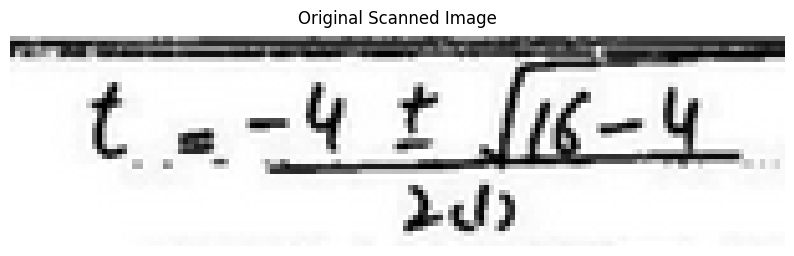

--------------------------------------------------
RAW OUTPUT (To be saved to .txt / .docx):
--------------------------------------------------
$$t = \frac {-4 \pm \sqrt { k - 4 } } { 2 k }$$
--------------------------------------------------


$$t = \frac {-4 \pm \sqrt { k - 4 } } { 2 k }$$

In [3]:
# Provide the path to a test image of handwritten notes
# (Make sure to place a sample image in the same directory or update this path)
sample_image_path = "test_math_images/test1.png" 

# You can optionally tweak the prompt to focus on specific behaviors
custom_prompt = None 

try:
    # Process the image
    print(f"\nProcessing {sample_image_path}...")
    transcribed_text = vlm.process_image(sample_image_path, custom_prompt=custom_prompt)

    # Visualize the results inline (Image, Raw Text, Rendered Markdown/LaTeX)
    vlm.visualize_result(sample_image_path, transcribed_text)
except FileNotFoundError:
    print(f"\n[!] ERROR: Could not find '{sample_image_path}'. Please add a test image to the directory.")